In [400]:
import numpy as np
from scipy import signal, fft
import matplotlib.pyplot as plt

In [401]:
n = 500
Fs = 1000
F_max = 9
a = 0
b = 10

random = np.random.normal(a, b, n)
t = np.arange(n)/Fs

In [402]:
w = F_max/(Fs/2)
parameters_filter = signal.butter(3, w, 'low', output='sos')
filtered_signal = signal.sosfiltfilt(parameters_filter, random)

In [403]:
def showResults(x, y, title, xlabel, ylabel):
    fig, ax = plt.subplots(figsize=(32 / 2.54, 18 / 2.54))
    ax.plot(x, y, linewidth=2)
    ax.set_xlabel(xlabel, fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    plt.title(title, fontsize=14)
    plt.grid()
    plt.savefig('./figures/' + title + '.png', dpi=600)

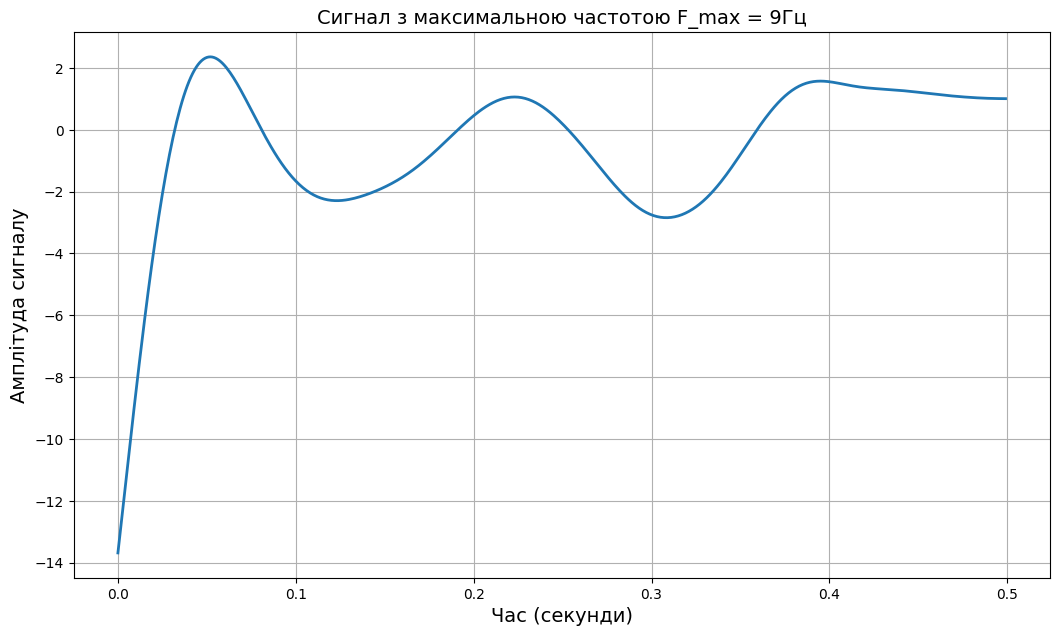

In [404]:
showResults(t, filtered_signal, 'Сигнал з максимальною частотою F_max = 9Гц' , 'Час (секунди)', 'Амплітуда сигналу')

In [405]:
spectrum = fft.fft(filtered_signal)
spectrum = np.abs(fft.fftshift(spectrum))
ticks = fft.fftfreq(n, 1 / n)
ticks = fft.fftshift(ticks)

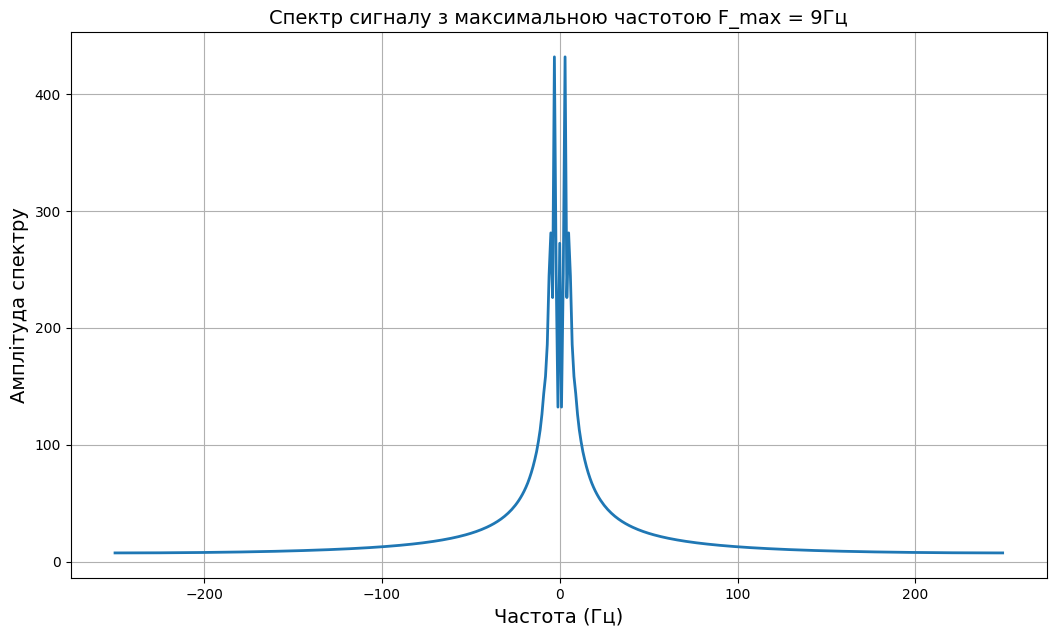

In [406]:
showResults(ticks, spectrum, 'Спектр сигналу з максимальною частотою F_max = 9Гц', 'Частота (Гц)', 'Амплітуда спектру')

In [407]:
F_filter = 16
w = F_filter/(Fs/2)
var_filtered_signal = np.var(filtered_signal)

discrete_signals = []
discrete_spectrums = []
discrete_filtered_signals = []
vars_discrete_filtered_signal = []
signal_noise = []

for Dt in [2, 4, 8, 16]:
    discrete_signal = np.zeros(n)
    for i in range(0, round(n / Dt)):
        discrete_signal[i * Dt] = filtered_signal[i * Dt]
    discrete_signals += [list(discrete_signal)]
    
    discrete_spectrum = fft.fft(discrete_signal)
    discrete_spectrum = np.abs(fft.fftshift(discrete_spectrum))
    discrete_spectrums += [list(discrete_spectrum)]

    parameters_filter = signal.butter(3, w, 'low', output='sos')
    discrete_filtered_signal = signal.sosfiltfilt(parameters_filter, discrete_signal)
    discrete_filtered_signals += [list(discrete_filtered_signal)]

    E1 = discrete_filtered_signal - filtered_signal
    var_discrete_filtered_signal = np.var(E1)
    vars_discrete_filtered_signal += [var_discrete_filtered_signal]
    signal_noise += [var_filtered_signal / var_discrete_filtered_signal]

In [408]:
def displayResultsSubplots(x, y, xlabel, ylabel, title):
    fig, ax = plt.subplots(2, 2, figsize=(21 / 2.54, 14 / 2.54))

    s = 0
    for i in range(0, 2):
        for j in range(0, 2):
            ax[i][j].plot(x, y[s], linewidth=1)
            s += 1

    fig.supxlabel(xlabel, fontsize=14)
    fig.supylabel(ylabel, fontsize=14)
    fig.suptitle(title, fontsize=14)
    fig.savefig('./figures/' + title + '.png', dpi=600)

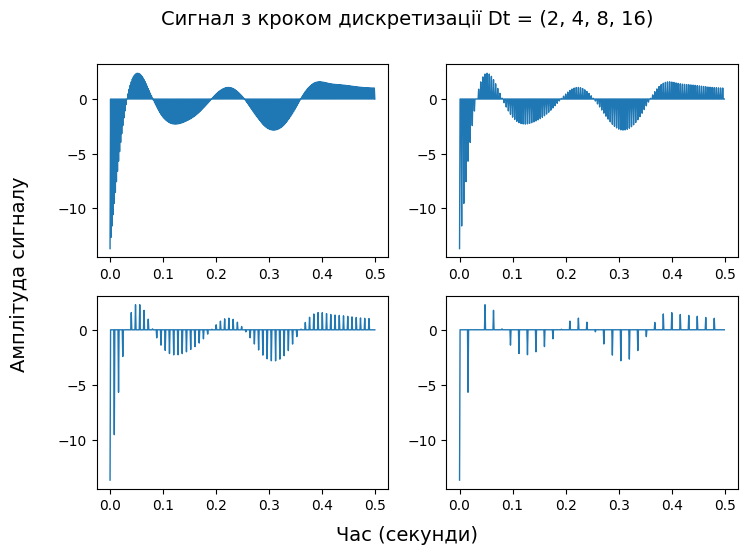

In [409]:
displayResultsSubplots(t, discrete_signals, 'Час (секунди)', 'Амплітуда сигналу', 'Сигнал з кроком дискретизації Dt = (2, 4, 8, 16)')

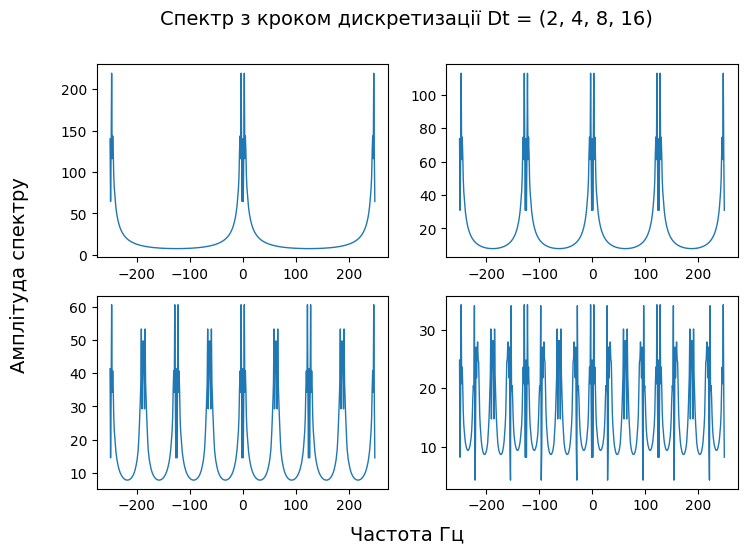

In [410]:
displayResultsSubplots(ticks , discrete_spectrums, 'Частота Гц', 'Амплітуда спектру', 'Спектр з кроком дискретизації Dt = (2, 4, 8, 16)')

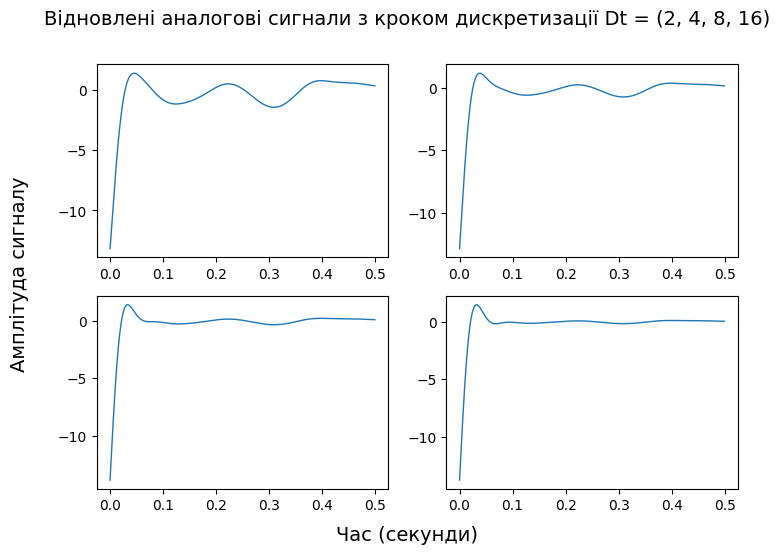

In [411]:
displayResultsSubplots(t , discrete_filtered_signals, 'Час (секунди)', 'Амплітуда сигналу', 'Відновлені аналогові сигнали з кроком дискретизації Dt = (2, 4, 8, 16)')

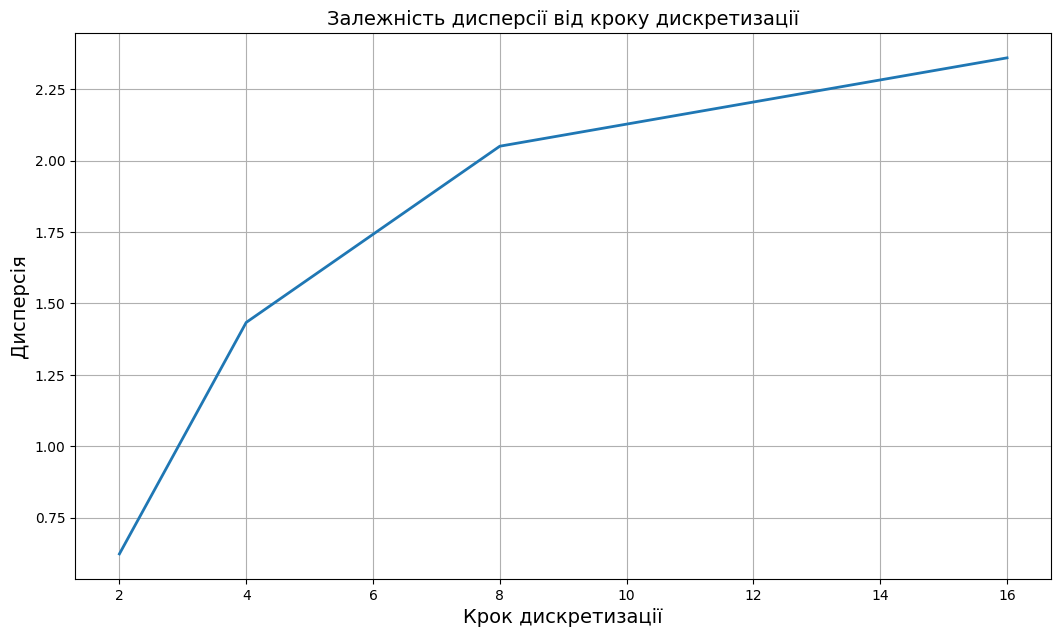

In [412]:
x = [2, 4, 8, 16]
showResults(x, vars_discrete_filtered_signal, 'Залежність дисперсії від кроку дискретизації', 'Крок дискретизації', 'Дисперсія')

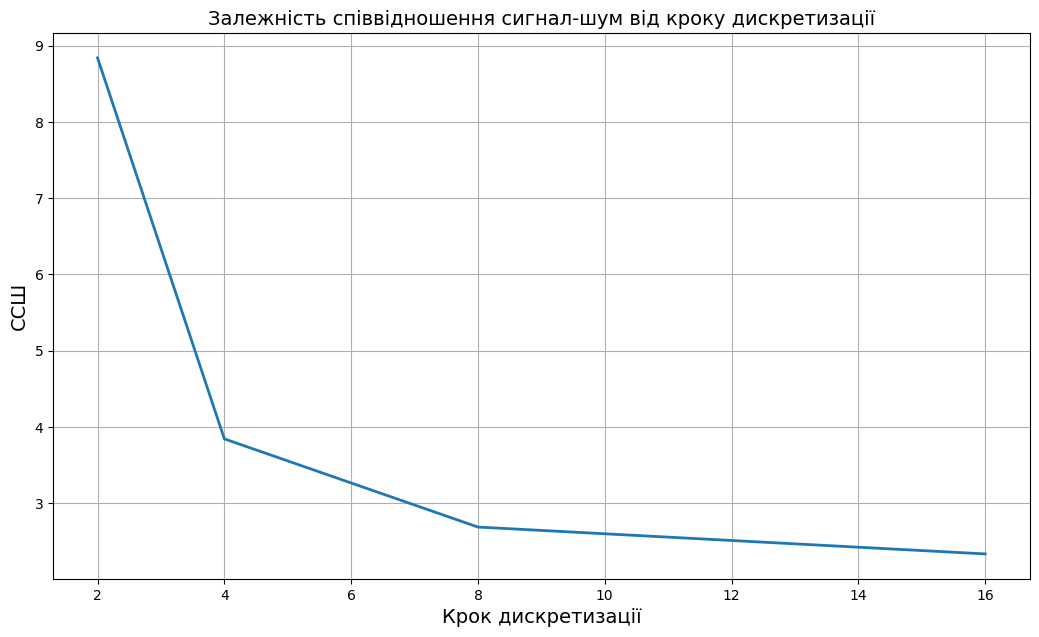

In [413]:
showResults(x, signal_noise, 'Залежність співвідношення сигнал-шум від кроку дискретизації', 'Крок дискретизації', 'CCШ')